In [35]:
# IMPORT LIBRARY
# library utama
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [36]:
# LOAD DATA
df = pd.read_csv("Diamond Price Prediction.csv")
df.head()

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


In [38]:
# DATA UNDERSTANDING
df.columns = df.columns.str.strip()
list(df.columns)

['Carat(Weight of Daimond)',
 'Cut(Quality)',
 'Color',
 'Clarity',
 'Depth',
 'Table',
 'Price(in US dollars)',
 'X(length)',
 'Y(width)',
 'Z(Depth)']

In [39]:
# shape data
df.shape

(22585, 10)

In [40]:
# info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22585 entries, 0 to 22584
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Carat(Weight of Daimond)  22585 non-null  float64
 1   Cut(Quality)              22585 non-null  object 
 2   Color                     22585 non-null  object 
 3   Clarity                   22584 non-null  object 
 4   Depth                     22584 non-null  float64
 5   Table                     22584 non-null  float64
 6   Price(in US dollars)      22584 non-null  float64
 7   X(length)                 22584 non-null  float64
 8   Y(width)                  22584 non-null  float64
 9   Z(Depth)                  22584 non-null  float64
dtypes: float64(7), object(3)
memory usage: 1.7+ MB


In [41]:
# missing value
df.isnull().sum()

,0
Carat(Weight of Daimond),0
Cut(Quality),0
Color,0
Clarity,1
Depth,1
Table,1
Price(in US dollars),1
X(length),1
Y(width),1
Z(Depth),1


In [42]:
# statistik deskriptif
df.describe(include='all')

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
count,22585.000000,22585,22585,22584,22584.000000,22584.000000,22584.000000,22584.000000,22584.000000,22584.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,7457,4556,6163,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.996287,NaN,NaN,NaN,61.812651,57.754658,4992.725248,6.300332,6.299615,3.892197
std,0.330829,NaN,NaN,NaN,1.537011,2.216912,2429.919079,0.810807,0.799804,0.505980
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.900000,NaN,NaN,NaN,61.000000,56.000000,3468.000000,6.060000,6.060000,3.740000
50%,1.010000,NaN,NaN,NaN,61.900000,58.000000,4712.000000,6.430000,6.430000,3.990000
75%,1.170000,NaN,NaN,NaN,62.700000,59.000000,6526.000000,6.750000,6.742500,4.170000


In [43]:
# DATA PREPROCESSING
# cari target otomatis
target_candidates = [col for col in df.columns if 'price' in col.lower()]
target_col = target_candidates[0]
target_col

'Price(in US dollars)'

In [44]:
# drop kolom tidak penting
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

df.head()

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


In [45]:
# cek duplikat
df.duplicated().sum()

np.int64(50)

In [47]:
df.duplicated().sum()


np.int64(50)

In [48]:
# handle missing value
df = df.dropna()
df.isnull().sum()

,0
Carat(Weight of Daimond),0
Cut(Quality),0
Color,0
Clarity,0
Depth,0
Table,0
Price(in US dollars),0
X(length),0
Y(width),0
Z(Depth),0


In [49]:
# cek kolom kategorikal
df.select_dtypes(include='object').columns

Index(['Cut(Quality)', 'Color', 'Clarity'], dtype='object')

In [50]:
# ubah kategorikal ke numerik
df_model = pd.get_dummies(df, drop_first=True, dtype=int)
df_model.head()

,Carat(Weight of Daimond),Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth),Cut(Quality)_Good,Cut(Quality)_Ideal,Cut(Quality)_Premium,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
0,0.23,61.5,55.0,326.0,3.95,3.98,2.43,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326.0,3.89,3.84,2.31,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327.0,4.05,4.07,2.31,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334.0,4.20,4.23,2.63,0,0,1,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335.0,4.34,4.35,2.75,1,0,0,...,0,0,1,0,0,1,0,0,0,0


In [51]:
# cek semua tipe data
df_model.dtypes

,0
Carat(Weight of Daimond),float64
Depth,float64
Table,float64
Price(in US dollars),float64
X(length),float64
Y(width),float64
Z(Depth),float64
Cut(Quality)_Good,int64
Cut(Quality)_Ideal,int64
Cut(Quality)_Premium,int64


In [52]:
# handle outlier
kolom_numerik = df_model.select_dtypes(include=np.number).columns

Q1 = df_model[kolom_numerik].quantile(0.25)
Q3 = df_model[kolom_numerik].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df_model[kolom_numerik] < (Q1 - 1.5 * IQR)) |
         (df_model[kolom_numerik] > (Q3 + 1.5 * IQR))).any(axis=1)

df_model = df_model[mask]
df_model.shape

(433, 24)

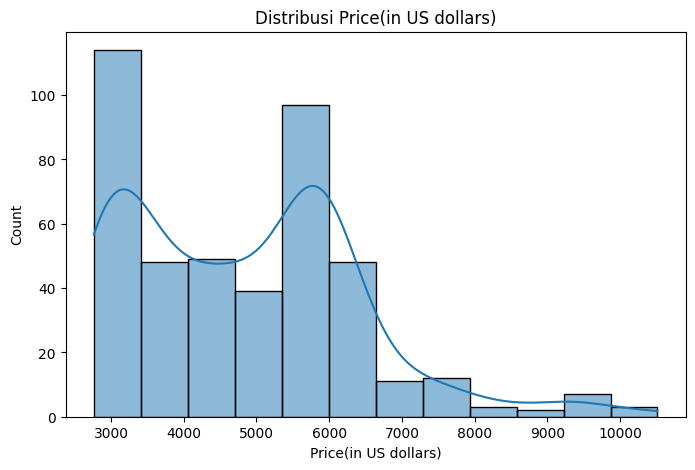

In [53]:
# EDA
# distribusi target
plt.figure(figsize=(8,5))
sns.histplot(df_model[target_col], kde=True)
plt.title(f'Distribusi {target_col}')
plt.show()

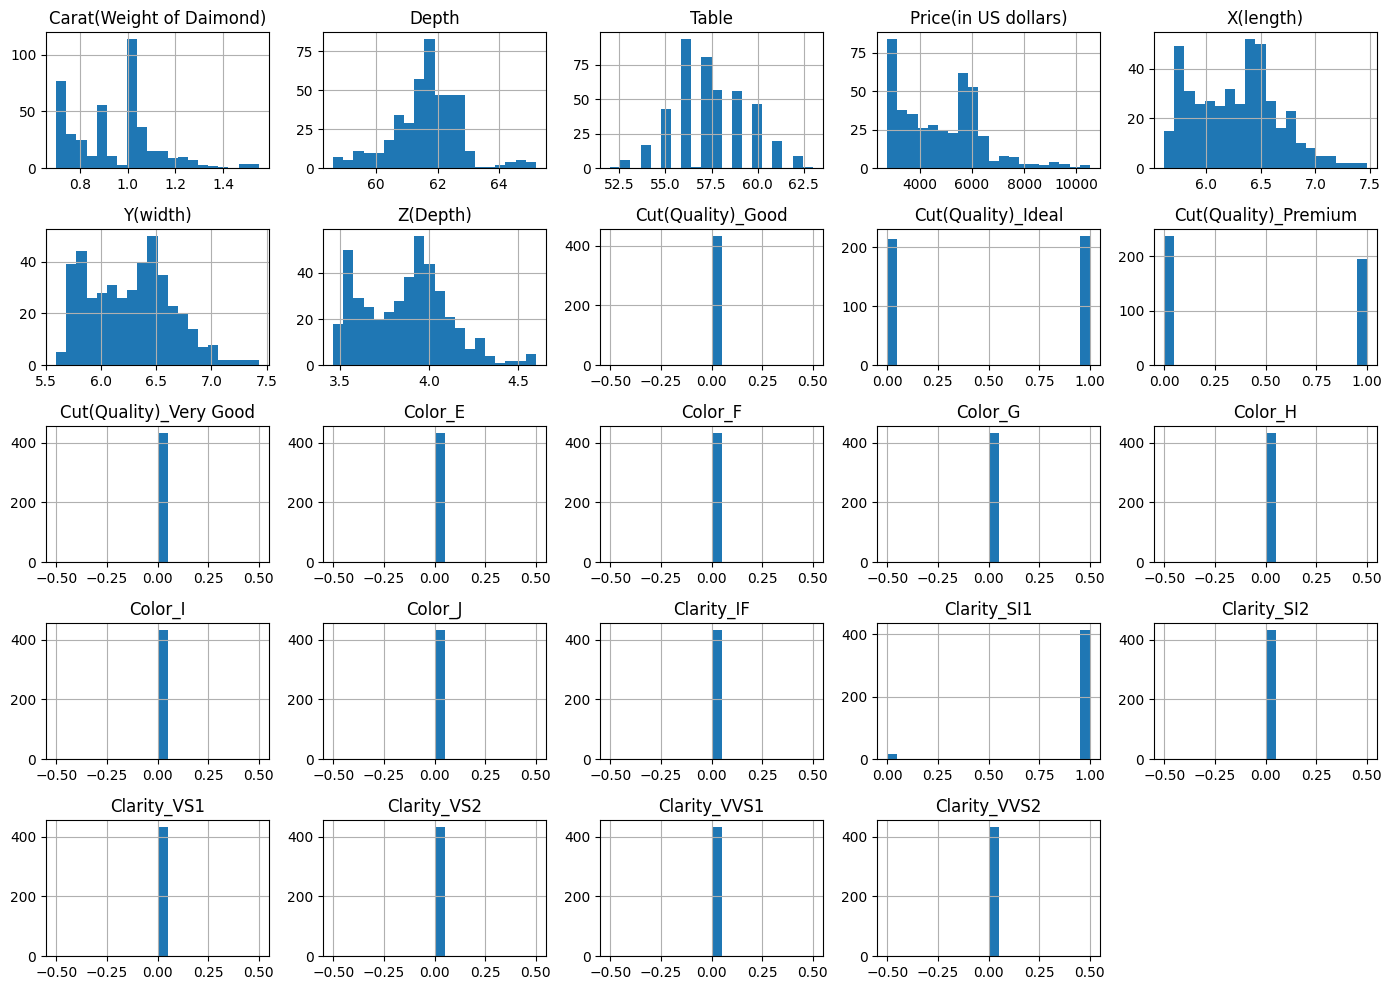

In [54]:
# distribusi fitur numerik
kolom_numerik_eda = df_model.select_dtypes(include=np.number).columns
df_model[kolom_numerik_eda].hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

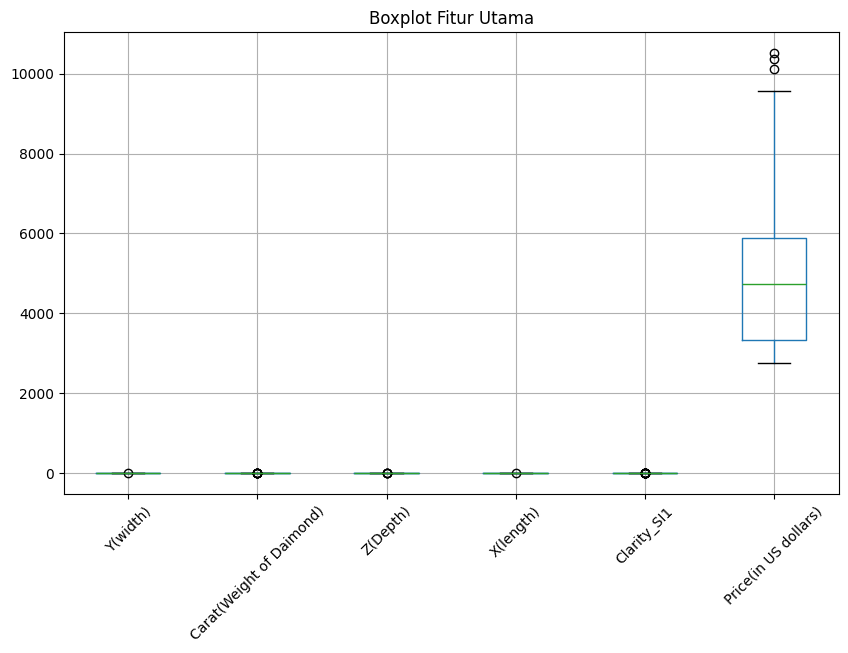

In [55]:
# boxplot fitur utama
corr_awal = df_model.corr(numeric_only=True)[[target_col]].sort_values(by=target_col, ascending=False)
fitur_boxplot = [col for col in corr_awal.index if col != target_col][:5]
fitur_boxplot.append(target_col)

plt.figure(figsize=(10,6))
df_model[fitur_boxplot].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot Fitur Utama')
plt.show()

In [56]:
# tabel korelasi target
corr_target = df_model.corr(numeric_only=True)[[target_col]].sort_values(by=target_col, ascending=False)
corr_target.head(10)

,Price(in US dollars)
Price(in US dollars),1.000000
Y(width),0.877402
Carat(Weight of Daimond),0.875526
Z(Depth),0.868666
X(length),0.866461
Clarity_SI1,0.069906
Depth,0.060138
Cut(Quality)_Premium,0.014287
Table,-0.003358
Cut(Quality)_Ideal,-0.030393


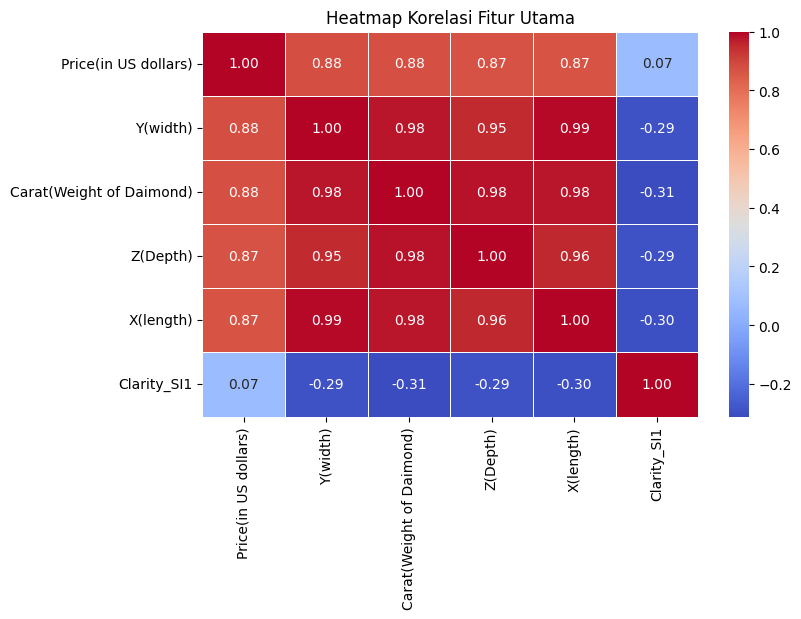

In [57]:
# heatmap korelasi
fitur_heatmap = corr_target.index[:6].tolist()

plt.figure(figsize=(8,5))
sns.heatmap(df_model[fitur_heatmap].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Utama')
plt.show()

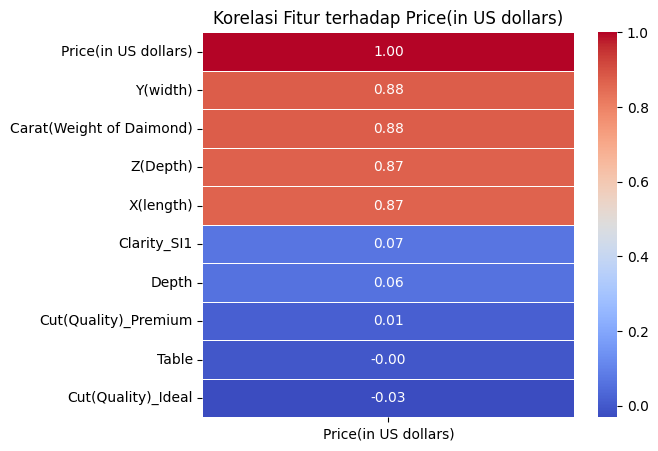

In [58]:
# heatmap korelasi target
plt.figure(figsize=(6,5))
sns.heatmap(corr_target.head(10), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'Korelasi Fitur terhadap {target_col}')
plt.show()

In [59]:
# DATA SPLITTING
# fitur dan target
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

X.head()

,Carat(Weight of Daimond),Depth,Table,X(length),Y(width),Z(Depth),Cut(Quality)_Good,Cut(Quality)_Ideal,Cut(Quality)_Premium,Cut(Quality)_Very Good,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
132,0.71,61.9,59.0,5.69,5.72,3.53,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
224,0.72,60.8,57.0,5.76,5.75,3.50,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
225,0.72,62.7,59.0,5.73,5.69,3.58,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
226,0.70,62.8,60.0,5.68,5.66,3.56,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
288,0.71,62.7,60.0,5.67,5.71,3.57,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [60]:
# split 70 30
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [61]:
# split 80 20
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
# split 90 10
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [63]:
# NORMALISASI
# normalisasi 70 30
scaler_70 = StandardScaler()
X_train_70_scaled = scaler_70.fit_transform(X_train_70)
X_test_70_scaled = scaler_70.transform(X_test_70)

In [64]:
# normalisasi 80 20
scaler_80 = StandardScaler()
X_train_80_scaled = scaler_80.fit_transform(X_train_80)
X_test_80_scaled = scaler_80.transform(X_test_80)

In [65]:
# normalisasi 90 10
scaler_90 = StandardScaler()
X_train_90_scaled = scaler_90.fit_transform(X_train_90)
X_test_90_scaled = scaler_90.transform(X_test_90)

In [66]:
# normalisasi 90 10
scaler_90 = StandardScaler()
X_train_90_scaled = scaler_90.fit_transform(X_train_90)
X_test_90_scaled = scaler_90.transform(X_test_90)

In [69]:
# EVALUASI FUNCTION
# fungsi evaluasi regresi
def evaluasi_regresi(y_true, y_pred):
    return pd.DataFrame({
        'MAE': [mean_absolute_error(y_true, y_pred)],
        'MSE': [mean_squared_error(y_true, y_pred)],
        'RMSE': [np.sqrt(mean_squared_error(y_true, y_pred))],
        'R2': [r2_score(y_true, y_pred)]
    })

In [70]:
# MODEL XGBOOST
# training model awal
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_80_scaled, y_train_80)

y_pred_xgb = xgb_model.predict(X_test_80_scaled)

In [71]:
# evaluasi model awal
hasil_xgb_awal = evaluasi_regresi(y_test_80, y_pred_xgb)
hasil_xgb_awal

,MAE,MSE,RMSE,R2
0,357.536251,221012.584949,470.119756,0.930975


In [72]:
# HYPERPARAMETER XGBOOST
# tuning xgboost
param_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train_80_scaled, y_train_80)

pd.DataFrame([grid_xgb.best_params_])

,learning_rate,max_depth,n_estimators
0,0.05,3,200


In [73]:
# evaluasi setelah tuning
best_xgb = grid_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_80_scaled)

hasil_xgb_tuned = evaluasi_regresi(y_test_80, y_pred_xgb_tuned)
hasil_xgb_tuned

,MAE,MSE,RMSE,R2
0,310.371105,181341.311455,425.841886,0.943365


In [74]:
# MODEL LIGHTGBM
# training model awal
lgbm_model = LGBMRegressor(random_state=42)
lgbm_model.fit(X_train_80_scaled, y_train_80)

y_pred_lgbm = lgbm_model.predict(X_test_80_scaled)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 338
[LightGBM] [Info] Number of data points in the train set: 346, number of used features: 8
[LightGBM] [Info] Start training from score 4854.156069
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [75]:
# evaluasi model awal
hasil_lgbm_awal = evaluasi_regresi(y_test_80, y_pred_lgbm)
hasil_lgbm_awal

,MAE,MSE,RMSE,R2
0,447.152596,489738.631295,699.813283,0.847048


In [76]:
# HYPERPARAMETER LIGHTGBM
# tuning lightgbm
param_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_lgbm = GridSearchCV(
    estimator=LGBMRegressor(random_state=42),
    param_grid=param_lgbm,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_lgbm.fit(X_train_80_scaled, y_train_80)

pd.DataFrame([grid_lgbm.best_params_])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 338
[LightGBM] [Info] Number of data points in the train set: 346, number of used features: 8
[LightGBM] [Info] Start training from score 4854.156069
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,learning_rate,max_depth,n_estimators
0,0.05,5,200


In [77]:
# evaluasi setelah tuning
best_lgbm = grid_lgbm.best_estimator_
y_pred_lgbm_tuned = best_lgbm.predict(X_test_80_scaled)

hasil_lgbm_tuned = evaluasi_regresi(y_test_80, y_pred_lgbm_tuned)
hasil_lgbm_tuned

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,MSE,RMSE,R2
0,433.010832,458954.449347,677.46177,0.856663


In [78]:
# MODEL HISTGRADIENTBOOSTING
# training model awal
hgb_model = HistGradientBoostingRegressor(random_state=42)
hgb_model.fit(X_train_80_scaled, y_train_80)

y_pred_hgb = hgb_model.predict(X_test_80_scaled)

In [79]:
# evaluasi model awal
hasil_hgb_awal = evaluasi_regresi(y_test_80, y_pred_hgb)
hasil_hgb_awal

,MAE,MSE,RMSE,R2
0,439.977398,458257.091427,676.94689,0.856881


In [80]:
# HYPERPARAMETER HISTGRADIENTBOOSTING
# tuning histgradientboosting
param_hgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'max_iter': [100, 200]
}

grid_hgb = GridSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=42),
    param_grid=param_hgb,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_hgb.fit(X_train_80_scaled, y_train_80)

pd.DataFrame([grid_hgb.best_params_])

,learning_rate,max_depth,max_iter
0,0.1,5,100


In [82]:
# evaluasi setelah tuning
best_hgb = grid_hgb.best_estimator_
y_pred_hgb_tuned = best_hgb.predict(X_test_80_scaled)

hasil_hgb_tuned = evaluasi_regresi(y_test_80, y_pred_hgb_tuned)
hasil_hgb_tuned

,MAE,MSE,RMSE,R2
0,436.087315,450673.137561,671.321933,0.859249


In [83]:
# MODEL EVALUATION
# ringkasan xgboost
ringkasan_xgb = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'MAE': [hasil_xgb_awal['MAE'][0], hasil_xgb_tuned['MAE'][0]],
    'MSE': [hasil_xgb_awal['MSE'][0], hasil_xgb_tuned['MSE'][0]],
    'RMSE': [hasil_xgb_awal['RMSE'][0], hasil_xgb_tuned['RMSE'][0]],
    'R2': [hasil_xgb_awal['R2'][0], hasil_xgb_tuned['R2'][0]]
})

ringkasan_xgb

,Tahap,MAE,MSE,RMSE,R2
0,Sebelum Tuning,357.536251,221012.584949,470.119756,0.930975
1,Setelah Tuning,310.371105,181341.311455,425.841886,0.943365


In [84]:
# MODEL EVALUATION
# ringkasan lightgbm
ringkasan_lgbm = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'MAE': [hasil_lgbm_awal['MAE'][0], hasil_lgbm_tuned['MAE'][0]],
    'MSE': [hasil_lgbm_awal['MSE'][0], hasil_lgbm_tuned['MSE'][0]],
    'RMSE': [hasil_lgbm_awal['RMSE'][0], hasil_lgbm_tuned['RMSE'][0]],
    'R2': [hasil_lgbm_awal['R2'][0], hasil_lgbm_tuned['R2'][0]]
})

ringkasan_lgbm

,Tahap,MAE,MSE,RMSE,R2
0,Sebelum Tuning,447.152596,489738.631295,699.813283,0.847048
1,Setelah Tuning,433.010832,458954.449347,677.461770,0.856663


In [85]:
# MODEL EVALUATION
# ringkasan histgradientboosting
ringkasan_hgb = pd.DataFrame({
    'Tahap': ['Sebelum Tuning', 'Setelah Tuning'],
    'MAE': [hasil_hgb_awal['MAE'][0], hasil_hgb_tuned['MAE'][0]],
    'MSE': [hasil_hgb_awal['MSE'][0], hasil_hgb_tuned['MSE'][0]],
    'RMSE': [hasil_hgb_awal['RMSE'][0], hasil_hgb_tuned['RMSE'][0]],
    'R2': [hasil_hgb_awal['R2'][0], hasil_hgb_tuned['R2'][0]]
})

ringkasan_hgb

,Tahap,MAE,MSE,RMSE,R2
0,Sebelum Tuning,439.977398,458257.091427,676.946890,0.856881
1,Setelah Tuning,436.087315,450673.137561,671.321933,0.859249


In [86]:
# MODEL COMPARISON
# perbandingan semua model
evaluation_model = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'HistGradientBoosting'],
    'MAE Awal': [
        hasil_xgb_awal['MAE'][0],
        hasil_lgbm_awal['MAE'][0],
        hasil_hgb_awal['MAE'][0]
    ],
    'MSE Awal': [
        hasil_xgb_awal['MSE'][0],
        hasil_lgbm_awal['MSE'][0],
        hasil_hgb_awal['MSE'][0]
    ],
    'RMSE Awal': [
        hasil_xgb_awal['RMSE'][0],
        hasil_lgbm_awal['RMSE'][0],
        hasil_hgb_awal['RMSE'][0]
    ],
    'R2 Awal': [
        hasil_xgb_awal['R2'][0],
        hasil_lgbm_awal['R2'][0],
        hasil_hgb_awal['R2'][0]
    ],
    'MAE Setelah Tuning': [
        hasil_xgb_tuned['MAE'][0],
        hasil_lgbm_tuned['MAE'][0],
        hasil_hgb_tuned['MAE'][0]
    ],
    'MSE Setelah Tuning': [
        hasil_xgb_tuned['MSE'][0],
        hasil_lgbm_tuned['MSE'][0],
        hasil_hgb_tuned['MSE'][0]
    ],
    'RMSE Setelah Tuning': [
        hasil_xgb_tuned['RMSE'][0],
        hasil_lgbm_tuned['RMSE'][0],
        hasil_hgb_tuned['RMSE'][0]
    ],
    'R2 Setelah Tuning': [
        hasil_xgb_tuned['R2'][0],
        hasil_lgbm_tuned['R2'][0],
        hasil_hgb_tuned['R2'][0]
    ]
})

evaluation_model

,Model,MAE Awal,MSE Awal,RMSE Awal,R2 Awal,MAE Setelah Tuning,MSE Setelah Tuning,RMSE Setelah Tuning,R2 Setelah Tuning
0,XGBoost,357.536251,221012.584949,470.119756,0.930975,310.371105,181341.311455,425.841886,0.943365
1,LightGBM,447.152596,489738.631295,699.813283,0.847048,433.010832,458954.449347,677.461770,0.856663
2,HistGradientBoosting,439.977398,458257.091427,676.946890,0.856881,436.087315,450673.137561,671.321933,0.859249


In [87]:
# INFERENCE
# data sample
sample_data = X.iloc[[0]]
sample_data

,Carat(Weight of Daimond),Depth,Table,X(length),Y(width),Z(Depth),Cut(Quality)_Good,Cut(Quality)_Ideal,Cut(Quality)_Premium,Cut(Quality)_Very Good,...,Color_H,Color_I,Color_J,Clarity_IF,Clarity_SI1,Clarity_SI2,Clarity_VS1,Clarity_VS2,Clarity_VVS1,Clarity_VVS2
132,0.71,61.9,59.0,5.69,5.72,3.53,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0


In [88]:
# hasil prediksi
sample_scaled = scaler_80.transform(sample_data)
prediksi = best_xgb.predict(sample_scaled)

pd.DataFrame({
    f'Prediksi {target_col}': prediksi
})

,Prediksi Price(in US dollars)
0,2978.883545


In [89]:
# SAVE MODEL
# simpan model
joblib.dump(best_xgb, 'best_xgb_model.pkl')
joblib.dump(scaler_80, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

In [91]:
# DEPLOYMENT
# buat app streamlit
app_code = f"""
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('best_xgb_model.pkl')
scaler = joblib.load('scaler.pkl')
feature_columns = joblib.load('feature_columns.pkl')

st.title('Prediksi Harga Berlian')
st.write('Aplikasi sederhana untuk memprediksi {target_col}')

input_data = pd.DataFrame(0, index=[0], columns=feature_columns)

for col in feature_columns:
    if col.startswith('cut_') or col.startswith('color_') or col.startswith('clarity_'):
        continue
    input_data.loc[0, col] = st.number_input(col, value=1.0)

if st.button('Prediksi'):
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    st.success(f'Prediksi {target_col}: {{prediction[0]:.2f}}')
"""

with open('app.py', 'w') as f:
    f.write(app_code)

pd.DataFrame({'file': ['app.py'], 'status': ['berhasil dibuat']})

,file,status
0,app.py,berhasil dibuat


In [92]:
# DEPLOYMENT
# jalankan app
!python -m streamlit run app.py

/usr/bin/python3: No module named streamlit
